In [2]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation


In [3]:
## Heat budget details:
    # Box region: 25-35W, 52-58N
    # Model: 1/4 degree, monthly mean
    # Desnity of seawater: 1025 Kg/m3
    # Speciic heat capacity of seawater: 4000 J/Kg/K
    # Assume constant mixed layer heat temperature

In [4]:
# Open model and config files
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to North Atlantic 
bbox = (-35.0, -25.0, 52.0, 58.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt = dt_clipped.add_geoindex(grid="gridT")


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [5]:
dt['gridT']['T_MLD_Product'] = dt['gridT']['tos_con'] * dt['gridT']['somxl010']

In [6]:
dt

<xarray.DataTree>
Group: /
│   Dimensions:               (time_counter: 420, axis_nbounds: 2)
│   Coordinates:
│     * time_counter          (time_counter) datetime64[ns] 3kB 1990-01-16T12:00:...
│       time_centered         (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 7kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 7kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   None
│       iperio:   False
├── Group: /gridT
│       Dimensions:                (time_counter: 420, j: 37, i: 38, axis_nbounds: 2,
│                                   k: 75)
│       Coordinates:
│         * j                      (j) int64 296B 926 927 928 929 ... 959 960 961 962
│         * i                      (i) int64 304B 1011 1012 1013 1014 ... 1046 1047 1048
│         * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│           time_centered          (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
│         * gphit                  (j, i) float64 11kB 52.07 52.07 52.08 ... 57.98 57.98
│         * glamt                  (j, i) float64 11kB -34.87 -34.6 ... -25.31 -25.03
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/58)
│           berg_latent_heat_flux  (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           empmr                  (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           evs                    (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           ficeberg               (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           friver                 (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           hfevapds               (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│           ...                     ...
│           e2t                    (j, i) float64 11kB dask.array<chunksize=(37, 38), meta=np.ndarray>
│           top_level              (j, i) int32 6kB dask.array<chunksize=(37, 38), meta=np.ndarray>
│           bottom_level           (j, i) int32 6kB dask.array<chunksize=(37, 38), meta=np.ndarray>
│           tmask                  (k, j, i) float64 844kB 1.0 1.0 1.0 ... 0.0 0.0 0.0
│           tmaskutil              (j, i) float64 11kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
│           T_MLD_Product          (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
│       Indexes:
│         ┌ gphit    NDPointIndex (SklearnGeoBallTreeAdapter)
│         └ glamt
│       Attributes:
│           nftype:   None
│           iperio:   False
├── Group: /gridU
│       Dimensions:       (j: 1206, i: 1440, k: 75)
│       Coordinates:
│         * j             (j) int64 10kB 1 2 3 4 5 6 7 ... 1201 1202 1203 1204 1205 1206
│         * i             (i) float64 12kB 1.5 2.5 3.5 ... 1.438e+03 1.44e+03 1.44e+03
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│           gphiu         (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           glamu         (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│       Data variables:
│           e1u           (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           e2u           (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           umask         (k, j, i) float64 1GB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
│           umaskutil     (j, i) float64 14MB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
│       Attributes:
│           nftype:   None
│     

In [7]:
## Create time series. 

H_ts = (dt.integral(grid='gridT', var='T_MLD_Product', dims=['i', 'j'])) * 1025 * 4000
H_ts_final = H_ts.compute()            

In [8]:
seconds_in_month = (dt['gridT']['time_counter'].dt.days_in_month * 24 * 60 * 60)
Q_ts = dt.integral(grid='gridT', var='hfds', dims=['i', 'j']) * seconds_in_month
Q_ts_final = Q_ts.compute()

In [15]:
deltaH = H_ts_final.diff(dim="time_counter")
deltaH['time_counter'] = H_ts_final['time_counter'].isel(time_counter=slice(0, -1))
Q = Q_ts_final.isel(time_counter = slice(0, 419))
residuals = deltaH - Q
ratio = residuals / deltaH
ratio_terms = abs(Q) / abs(residuals)

(-1.0, 5.0)

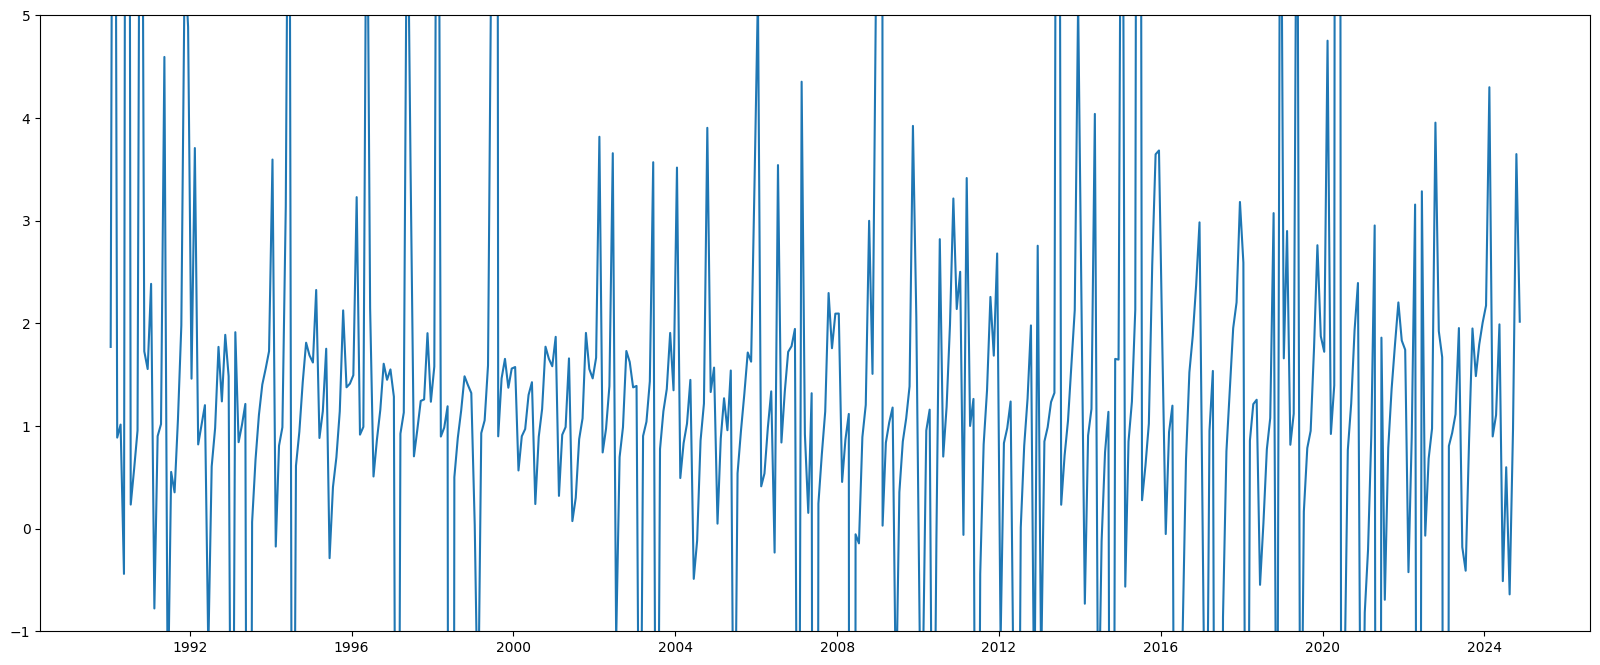

In [16]:
fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(ratio['time_counter'], ratio)
ax.set_ylim(-1,5)
# ax.set_xlim(np.datetime64('1991-01-01'), np.datetime64('1991-12-01'))

(-1.0, 5.0)

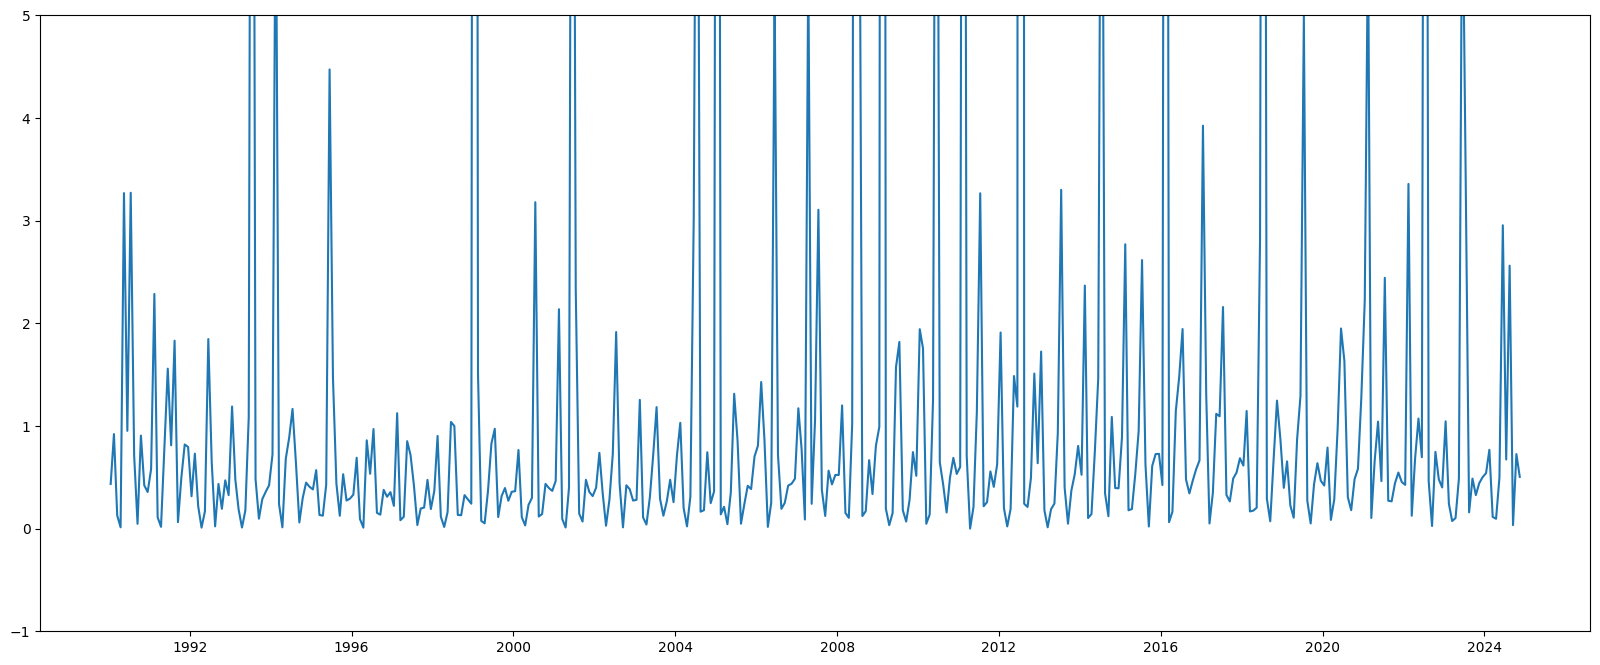

In [17]:
fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(ratio_terms['time_counter'], ratio_terms)
ax.set_ylim(-1,5)
#ax.set_xlim(np.datetime64('2000-01-01'), np.datetime64('2000-12-01'))

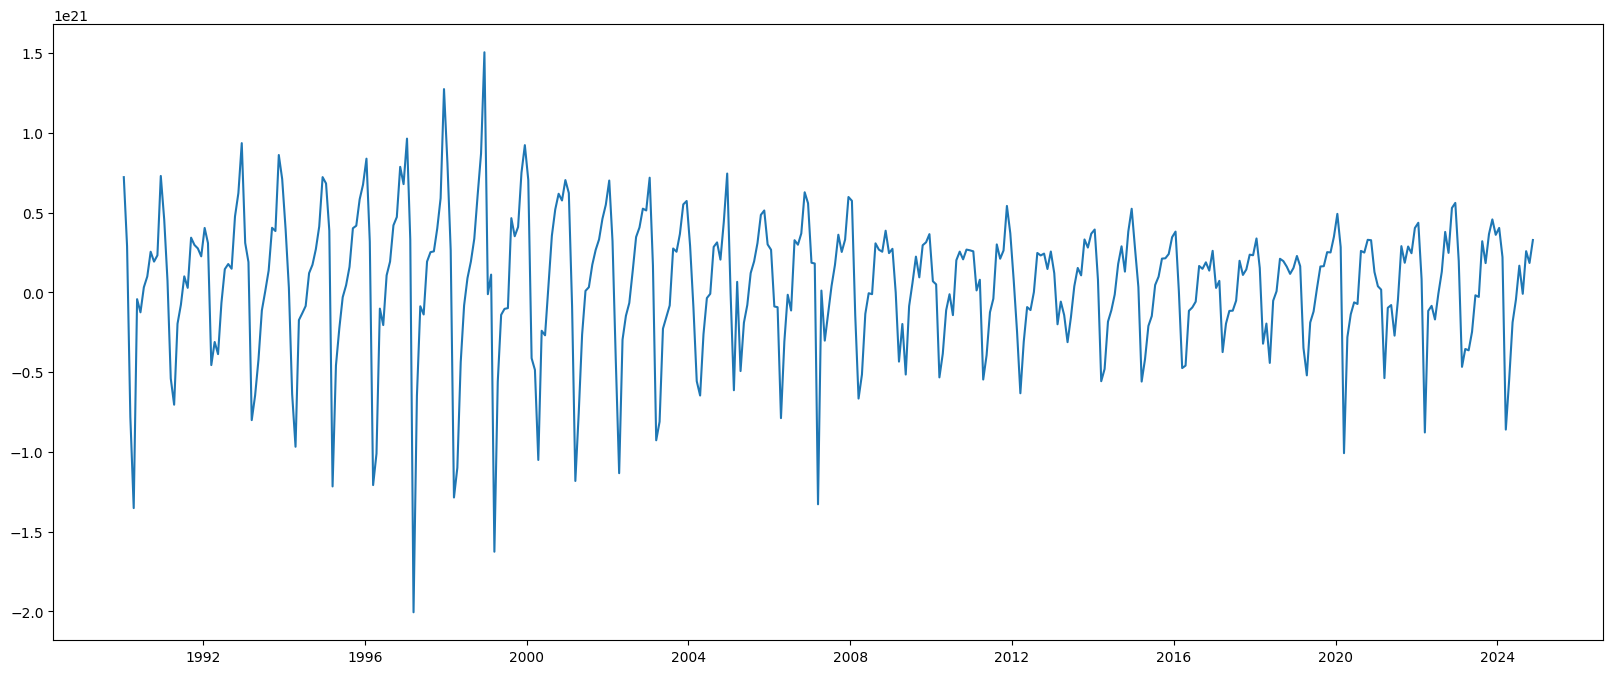

In [18]:
fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(residuals['time_counter'], residuals)
# ax.set_ylim(-1,5)
#ax.set_xlim(np.datetime64('2000-01-01'), np.datetime64('2000-12-01'))

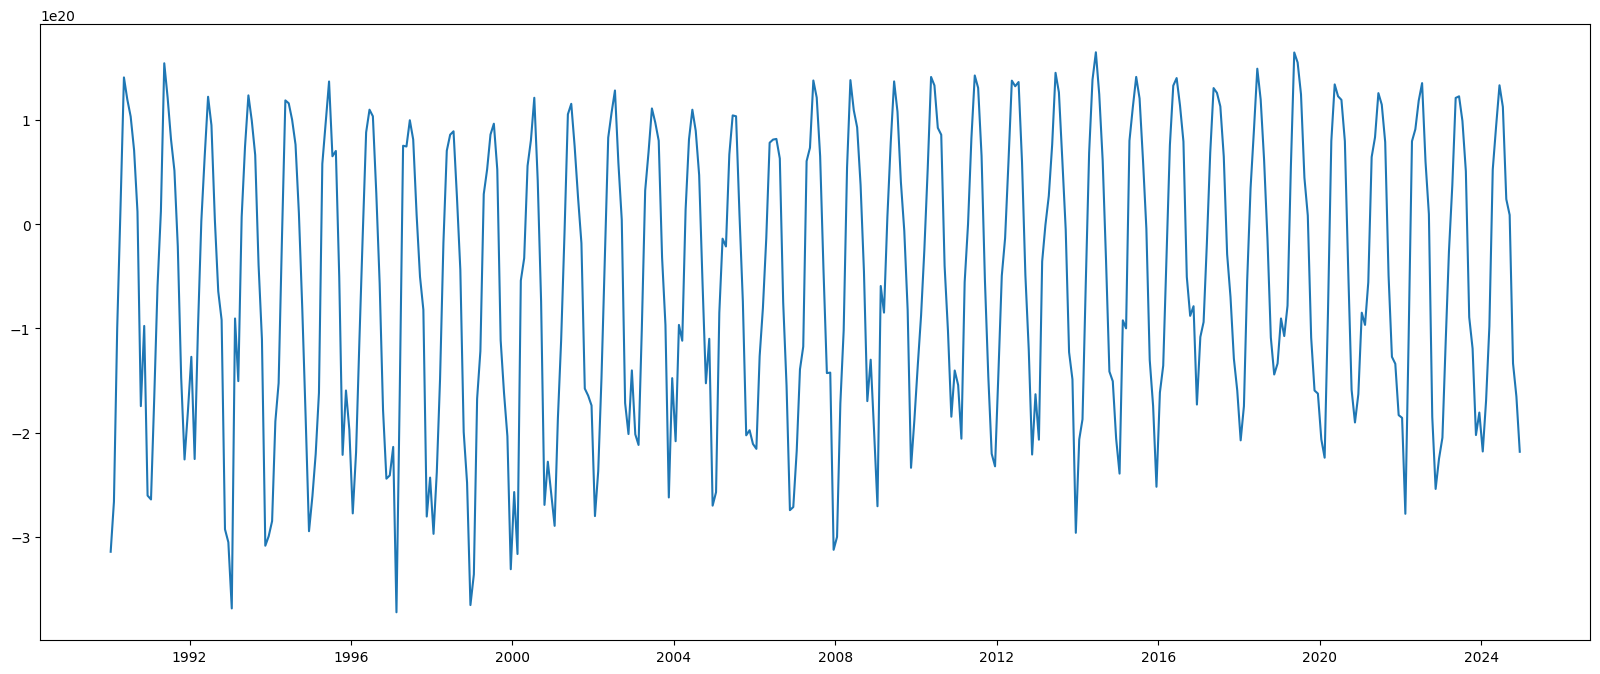

In [19]:
fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(Q_ts_final['time_counter'], Q_ts_final)
# ax.set_ylim(-1,5)
#ax.set_xlim(np.datetime64('2000-01-01'), np.datetime64('2000-12-01'))

(np.float64(12418.0), np.float64(13483.0))

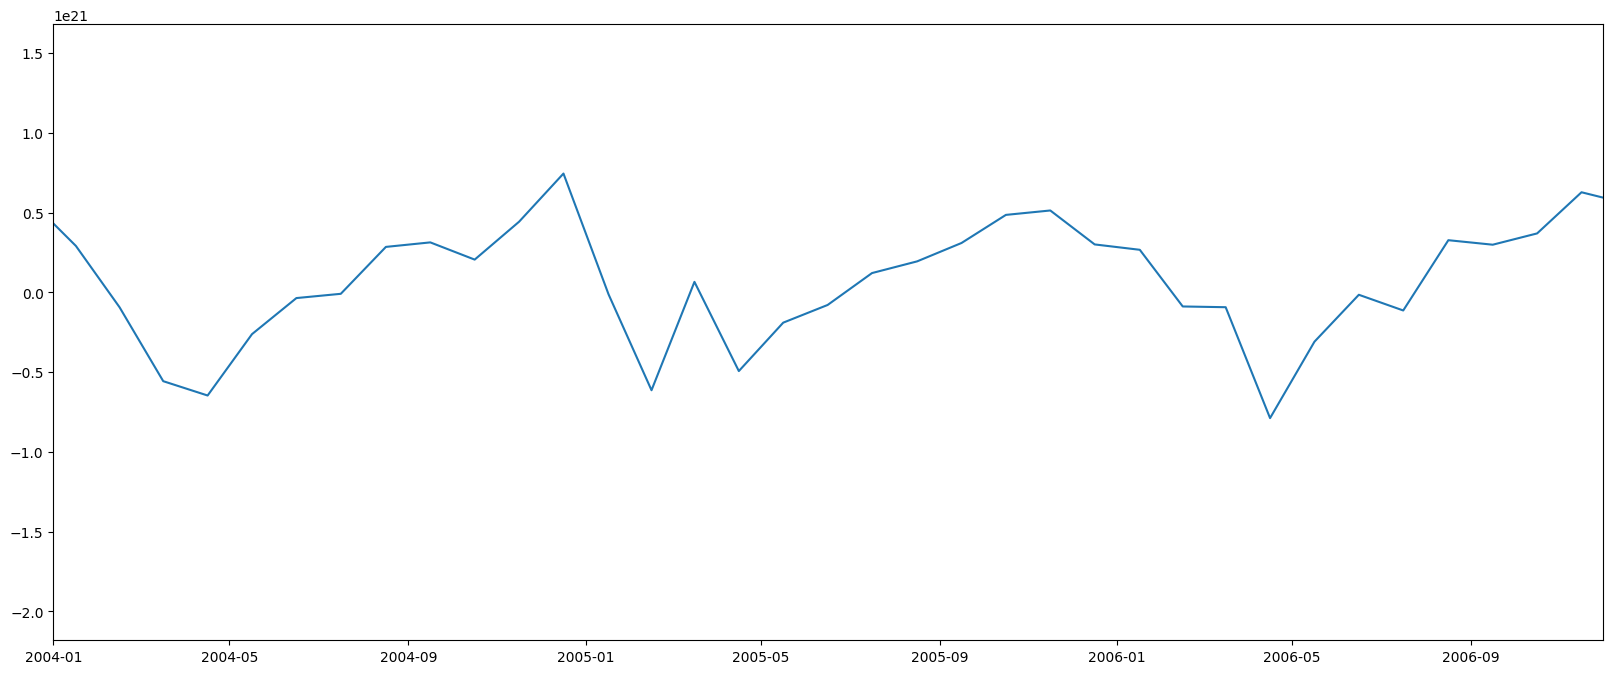

In [20]:
fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(residuals['time_counter'], residuals)
ax.set_xlim(np.datetime64('2004-01-01'), np.datetime64('2006-12-01'))

(np.float64(12418.0), np.float64(13483.0))

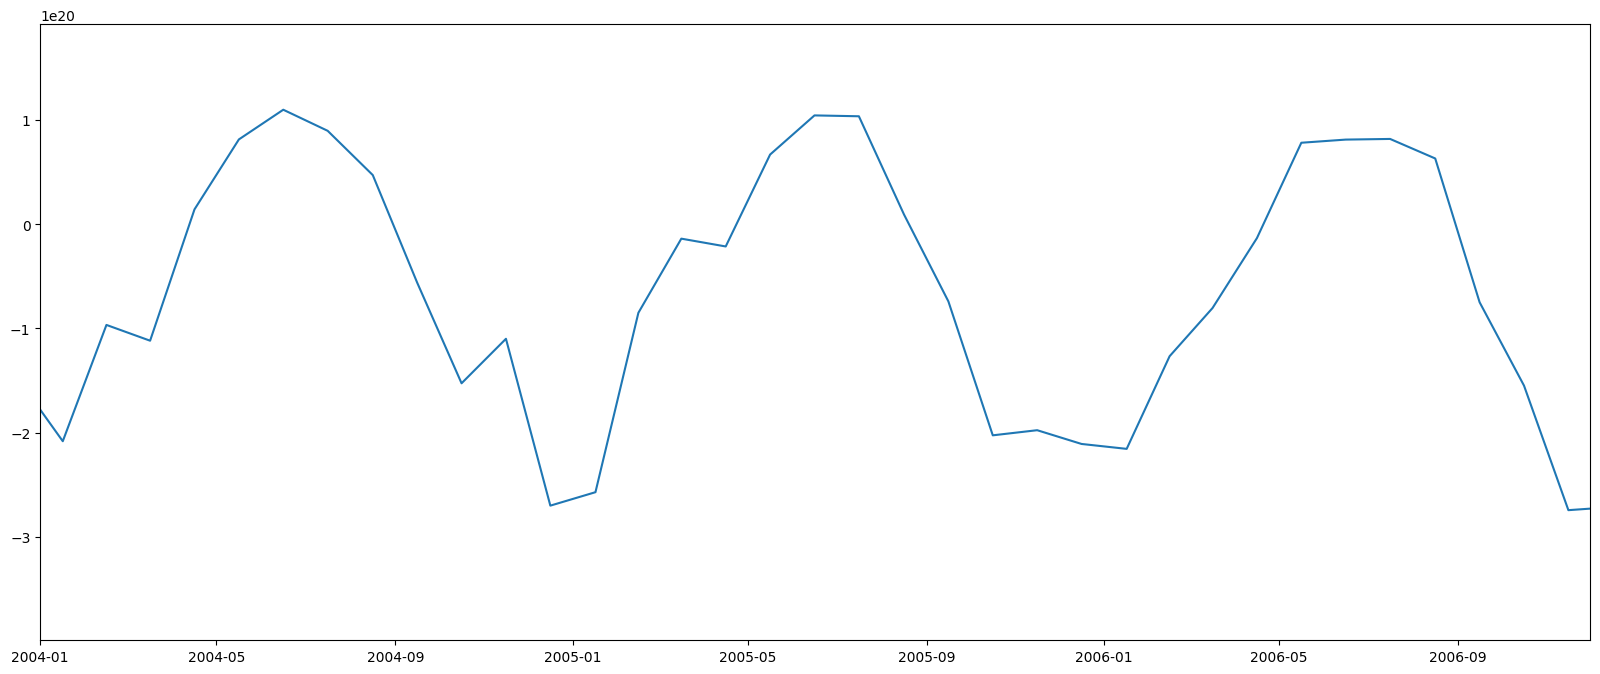

In [21]:
fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(Q_ts_final['time_counter'], Q_ts_final)
ax.set_xlim(np.datetime64('2004-01-01'), np.datetime64('2006-12-01'))

In [23]:
## Now consider annual means

Q_annual_mean = Q_ts_final.resample(time_counter='YE').mean()
residuals_annual_mean = residuals.resample(time_counter='YE').mean()


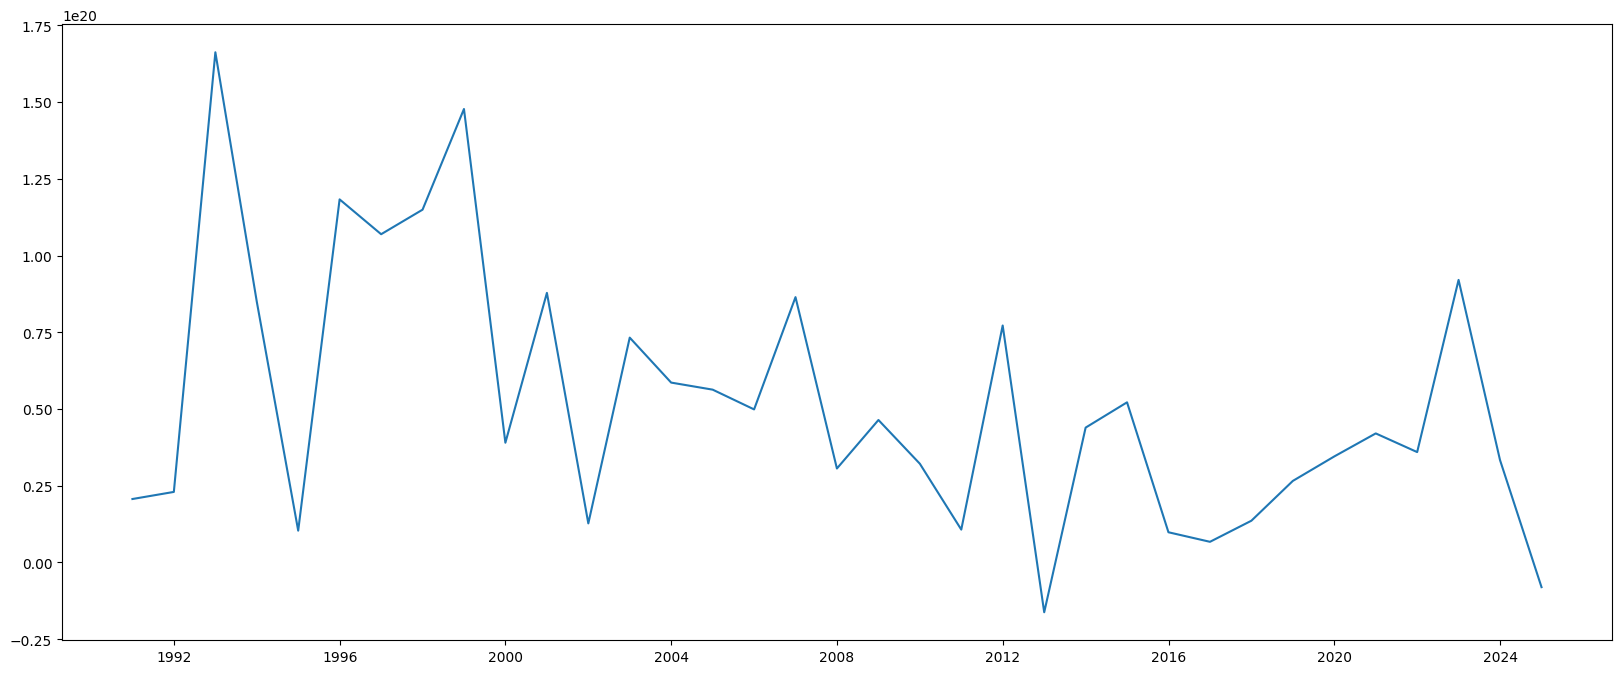

In [24]:
fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(residuals_annual_mean['time_counter'], residuals_annual_mean)
# ax.set_ylim(-1,5)
#ax.set_xlim(np.datetime64('2000-01-01'), np.datetime64('2000-12-01'))

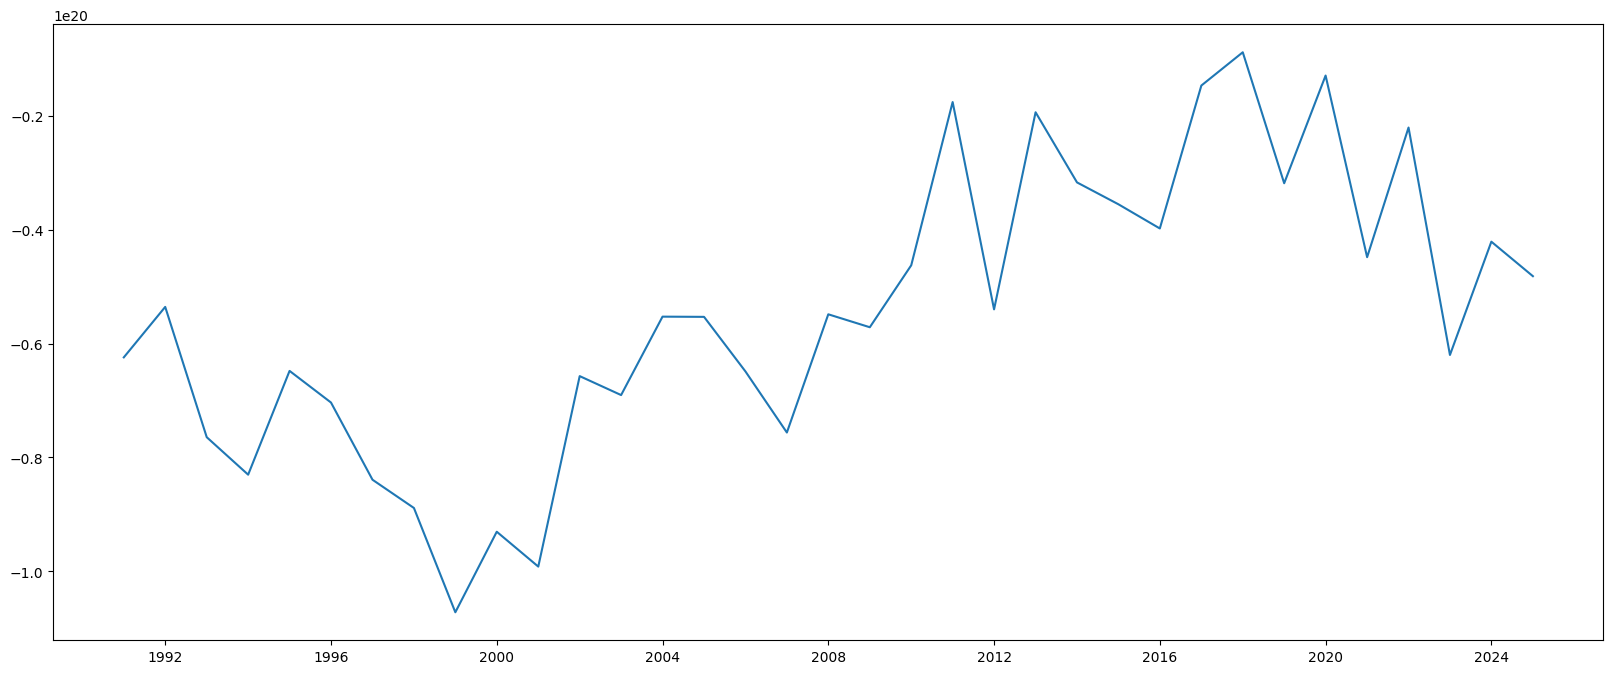

In [25]:
fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(Q_annual_mean['time_counter'], Q_annual_mean)
# ax.set_ylim(-1,5)
#ax.set_xlim(np.datetime64('2000-01-01'), np.datetime64('2000-12-01'))

In [27]:
ratio_terms = abs(Q_annual_mean) / abs(residuals_annual_mean)

(-1.0, 5.0)

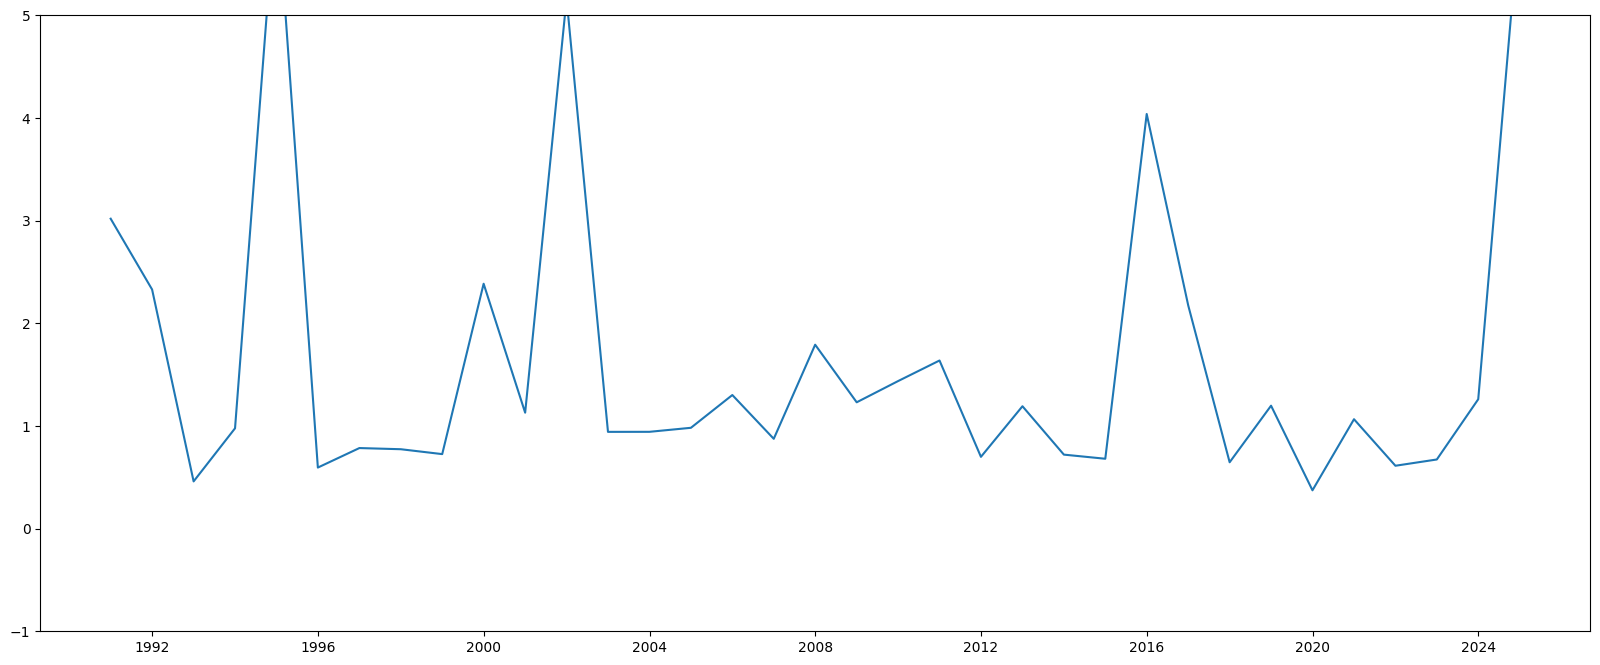

In [28]:
fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(ratio_terms['time_counter'], ratio_terms)
ax.set_ylim(-1,5)
#ax.set_xlim(np.datetime64('2000-01-01'), np.datetime64('2000-12-01'))